# Notebook 01 - Esplorazione dei dati
**Capstone: Analisi sulle aree interne italiane** | Strategia SNAI

In [1]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
import os
os.chdir(r"C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2")
print("Working directory", os.getcwd())

Working directory C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2


In [3]:
RAW_DIR = "data/raw/"
PROCESSED_DIR = "data/processed/"
OUTPUT_DIR = "OUTPUTS/"

## 1. Caricamento Dataset ISTAT Comuni Italiani
Fonte: ISTAT

In [4]:
df_comuni = pd.read_excel(RAW_DIR + "Elenco-comuni-italiani.xlsx", dtype=str)
print(f"Righe: {len(df_comuni)} | Colonne: {len(df_comuni.columns)}")
print("Prime colonne:", df_comuni.columns[:5].tolist())
df_comuni.head()

Righe: 7894 | Colonne: 27
Prime colonne: ['Codice Regione', "Codice dell'Unità territoriale sovracomunale \n(valida a fini statistici)", 'Codice Provincia (Storico)(1)', 'Progressivo del Comune (2)', 'Codice Comune formato alfanumerico']


,Codice Regione,Codice dell'Unità territoriale sovracomunale \n(valida a fini statistici),Codice Provincia (Storico)(1),Progressivo del Comune (2),Codice Comune formato alfanumerico,Denominazione (Italiana e straniera),Denominazione in italiano,Denominazione altra lingua,Codice Ripartizione Geografica,Ripartizione geografica,...,Codice Comune numerico con 110 Province (dal 2010 al 2016),Codice Comune numerico con 107 Province (dal 2006 al 2009),Codice Comune numerico con 103 Province (dal 1995 al 2005),Codice Catastale del Comune,Codice NUTS1 2021,Codice NUTS2 2021 (3),Codice NUTS3 2021,Codice NUTS1 2024,Codice NUTS2 2024 (3),Codice NUTS3 2024
0,01,201,001,001,001001,Agliè,Agliè,NaN,1,Nord-ovest,...,1001,1001,1001,A074,ITC,ITC1,ITC11,ITC,ITC1,ITC11
1,01,201,001,002,001002,Airasca,Airasca,NaN,1,Nord-ovest,...,1002,1002,1002,A109,ITC,ITC1,ITC11,ITC,ITC1,ITC11
2,01,201,001,003,001003,Ala di Stura,Ala di Stura,NaN,1,Nord-ovest,...,1003,1003,1003,A117,ITC,ITC1,ITC11,ITC,ITC1,ITC11
3,01,201,001,004,001004,Albiano d'Ivrea,Albiano d'Ivrea,NaN,1,Nord-ovest,...,1004,1004,1004,A157,ITC,ITC1,ITC11,ITC,ITC1,ITC11
4,01,201,001,006,001006,Almese,Almese,NaN,1,Nord-ovest,...,1006,1006,1006,A218,ITC,ITC1,ITC11,ITC,ITC1,ITC11


### Pulizia tabella

In [5]:
rename_map = {}
seen_r = set()
for col in df_comuni.columns:
    c = col.lower().replace("\n", " ").replace("\u00e0","a").replace("\u00e8","e").replace("\u00ec","i").replace("\u00f9","u").strip()
    import unicodedata
    c = unicodedata.normalize("NFKD", c).encode("ascii","ignore").decode()
    if "codice comune formato alfanumerico" in c and "codice_comune" not in seen_r:
        rename_map[col] = "codice_comune"; seen_r.add("codice_comune")
    elif "denominazione in italiano" in c and "comune" not in seen_r:
        rename_map[col] = "comune"; seen_r.add("comune")
    elif "denominazione regione" in c and "regione" not in seen_r:
        rename_map[col] = "regione"; seen_r.add("regione")
    elif ("sovracomunale" in c or "denominazione della provincia" in c or "denominazione dell" in c) and "provincia" not in seen_r:
        rename_map[col] = "provincia"; seen_r.add("provincia")
    elif "codice ripartizione" in c and "cod_ripartizione" not in seen_r:
        rename_map[col] = "cod_ripartizione"; seen_r.add("cod_ripartizione")
    elif "ripartizione geografica" in c and "ripartizione" not in seen_r:
        rename_map[col] = "ripartizione"; seen_r.add("ripartizione")
    elif "sigla automobilistica" in c and "sigla_prov" not in seen_r:
        rename_map[col] = "sigla_prov"; seen_r.add("sigla_prov")
    elif ("capoluogo" in c) and "capoluogo" not in seen_r:
        rename_map[col] = "capoluogo"; seen_r.add("capoluogo")

df_comuni = df_comuni.rename(columns=rename_map)
print("Colonne rinominate:", list(rename_map.values()))

if "capoluogo" in df_comuni.columns:
    df_comuni["capoluogo"] = df_comuni["capoluogo"].map({"SI": 1, "NO": 0}).fillna(0).astype(int)

df_comuni = df_comuni.dropna(subset=["codice_comune"])
print(f"Comuni validi dopo pulizia: {len(df_comuni)}")
df_comuni[["codice_comune","comune","regione","ripartizione","sigla_prov","capoluogo"]].head()

Colonne rinominate: ['provincia', 'codice_comune', 'comune', 'cod_ripartizione', 'ripartizione', 'regione', 'capoluogo', 'sigla_prov']
Comuni validi dopo pulizia: 7894


,codice_comune,comune,regione,ripartizione,sigla_prov,capoluogo
0,001001,Agliè,Piemonte,Nord-ovest,TO,0
1,001002,Airasca,Piemonte,Nord-ovest,TO,0
2,001003,Ala di Stura,Piemonte,Nord-ovest,TO,0
3,001004,Albiano d'Ivrea,Piemonte,Nord-ovest,TO,0
4,001006,Almese,Piemonte,Nord-ovest,TO,0


## 2. Caricamento classificazione SNAI
Fonte: ISTAT - calssificazione ufficiale SNAI 2021-2027 per ogni Comune


In [6]:
df_snai = pd.read_excel(RAW_DIR + "classificazione_snai.xlsx", header = 2, dtype=str)
print(f"righe: {len(df_snai)} | Colonne: {len(df_snai.columns)}")
df_snai.head()

righe: 7903 | Colonne: 16


,PROCOM_T,PROCOM_N,CODICE CATASTALE,COD_REG,REGIONE,COD_PROV,SIGLA AUTOM.,PROVINCIA/CITTA' METROPOLITANA,DENOMINAZIONE_COMUNE,CODICE_Aree_Interne 2014-2020,DESCRIZIONE_Aree_Interne 2014-2020,CODICE_Aree_Interne 2021-2027,DESCRIZIONE_Aree_Interne 2021-2027,PROCOM_Comune di destinazione prevalente \n(AI 2021-27),COMUNE di destinazione prevalente \n(AI 2021-27),CODICE POLO DI DESTINAZIONE PREVALENTE \n(AI 2021-27)
0,001001,1001,A074,1,Piemonte,201,TO,Torino,Agliè,C,C - Cintura,C,C - Cintura,1125,Ivrea,A - 01_03
1,001002,1002,A109,1,Piemonte,201,TO,Torino,Airasca,C,C - Cintura,C,C - Cintura,1191,Pinerolo,A - 01_05
2,001003,1003,A117,1,Piemonte,201,TO,Torino,Ala di Stura,E,E - Periferico,E,E - Periferico,1090,Collegno,B - 01_01
3,001004,1004,A157,1,Piemonte,201,TO,Torino,Albiano d'Ivrea,C,C - Cintura,C,C - Cintura,1125,Ivrea,A - 01_03
4,001006,1006,A218,1,Piemonte,201,TO,Torino,Almese,C,C - Cintura,C,C - Cintura,1090,Collegno,B - 01_01


In [7]:
print("Colonne SNAI:")
for i, c in enumerate(df_snai.columns):
    print(f" {i}: {repr(c)}")

Colonne SNAI:
 0: 'PROCOM_T'
 1: 'PROCOM_N'
 2: 'CODICE CATASTALE'
 3: 'COD_REG'
 4: 'REGIONE'
 5: 'COD_PROV'
 6: 'SIGLA AUTOM.'
 7: "PROVINCIA/CITTA' METROPOLITANA"
 8: 'DENOMINAZIONE_COMUNE'
 9: 'CODICE_Aree_Interne 2014-2020'
 10: 'DESCRIZIONE_Aree_Interne 2014-2020'
 11: 'CODICE_Aree_Interne 2021-2027'
 12: 'DESCRIZIONE_Aree_Interne 2021-2027'
 13: 'PROCOM_Comune di destinazione prevalente \n(AI 2021-27)'
 14: 'COMUNE di destinazione prevalente \n(AI 2021-27)'
 15: 'CODICE POLO DI DESTINAZIONE PREVALENTE \n(AI 2021-27)'


### Pulizia tabella

In [8]:
rename_snai = {}
seen = set()
for col in df_snai.columns:
    c = col.lower().strip()
    if "procom" in c and "codice_comune" not in seen:
        rename_snai[col] = "codice_comune"; seen.add("codice_comune")
    elif ("codice_aree" in c or "codice aree" in c) and "2021" in c and "classe_snai" not in seen:
        rename_snai[col] = "classe_snai"; seen.add("classe_snai")
    elif "descrizione" in c and "2021" in c and "desc_snai" not in seen:
        rename_snai[col] = "desc_snai"; seen.add("desc_snai")
    elif "codice" in c and "2014" in c and "classe_snai_old" not in seen:
        rename_snai[col] = "classe_snai_old"; seen.add("classe_snai_old")
    elif "descrizione" in c and "2014" in c and "desc_snai_old" not in seen:
        rename_snai[col] = "desc_snai_old"; seen.add("desc_snai_old")

df_snai = df_snai.rename(columns=rename_snai)

# Rimuoviamo eventuali colonne duplicate (tiene la prima occorrenza)
df_snai = df_snai.loc[:, ~df_snai.columns.duplicated()]
print("Colonne SNAI dopo rinomina:", df_snai.columns.tolist())

df_snai = df_snai.dropna(subset=["codice_comune"])
print(f"Record SNAI validi: {len(df_snai)}")
df_snai[["codice_comune","classe_snai","desc_snai"]].head()

Colonne SNAI dopo rinomina: ['codice_comune', 'PROCOM_N', 'CODICE CATASTALE', 'COD_REG', 'REGIONE', 'COD_PROV', 'SIGLA AUTOM.', "PROVINCIA/CITTA' METROPOLITANA", 'DENOMINAZIONE_COMUNE', 'classe_snai_old', 'desc_snai_old', 'classe_snai', 'desc_snai', 'PROCOM_Comune di destinazione prevalente \n(AI 2021-27)', 'COMUNE di destinazione prevalente \n(AI 2021-27)', 'CODICE POLO DI DESTINAZIONE PREVALENTE \n(AI 2021-27)']
Record SNAI validi: 7903


,codice_comune,classe_snai,desc_snai
0,001001,C,C - Cintura
1,001002,C,C - Cintura
2,001003,E,E - Periferico
3,001004,C,C - Cintura
4,001006,C,C - Cintura


### Distribuzione delle Classi SNAI

classe_snai              desc_snai    n
          A               A - Polo  182
          B B - Polo intercomunale   59
          C            C - Cintura 3828
          D         D - Intermedio 1928
          E         E - Periferico 1524
          F    F - Ultraperiferico  382


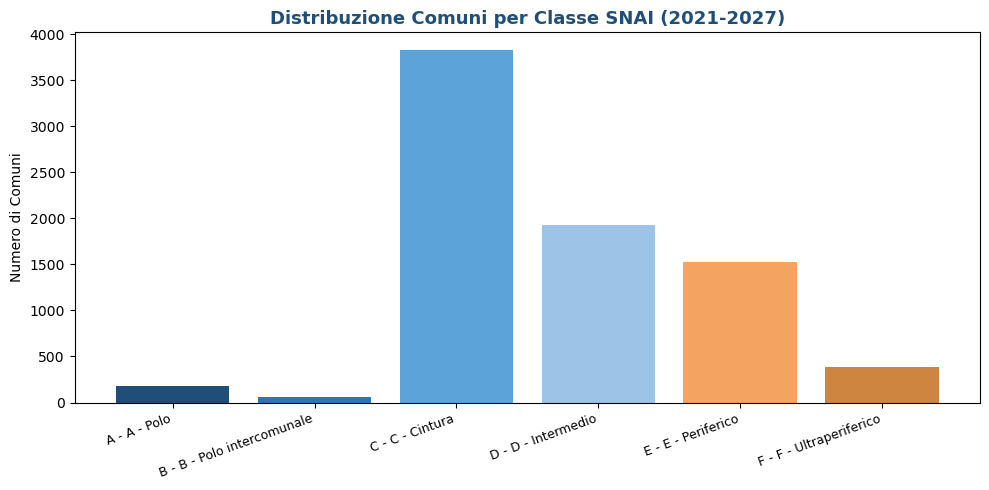

In [9]:
dist_snai = df_snai.groupby(["classe_snai","desc_snai"]).size().reset_index(name="n")
dist_snai = dist_snai.sort_values("classe_snai")
print(dist_snai.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
labels = [r.classe_snai + " - " + r.desc_snai for _, r in dist_snai.iterrows()]
colors_snai = ["#1F4E79","#2E75B6","#5BA3D9","#9DC3E6","#F4A460","#CD853F"]
ax.bar(labels, dist_snai["n"], color=colors_snai[:len(labels)])
ax.set_title("Distribuzione Comuni per Classe SNAI (2021-2027)",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.set_ylabel("Numero di Comuni")
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

## 3. JOIN tra Comuni e Classificazione SNAI
Per costruire il dataset di lavoro unisco la tabella dei comuni ISTAT con la classificazione SNAI tramite il codice comune.

Il JOIN è di tipo LEFT: parto dall'elenco completo dei comuni italiani e aggiungo sulla destra le informazioni SNAI dove disponibili. I comuni non classificati da SNAI (poli urbani e cinture) mantengono il record ma hanno classe_snai vuoto.

Dopo il join derivo la colonna is_area_interna: vale 1 per le classi D (Intermedio), E (Periferico) e F (Ultraperiferico), 0 per tutte le altre.

In [10]:
snai_cols = ["codice_comune"]
for c in ["classe_snai","desc_snai","classe_snai_old","desc_snai_old"]:
    if c in df_snai.columns:
        snai_cols.append(c)

df_master = df_comuni.merge(
    df_snai[snai_cols],
    on="codice_comune",
    how="left"
)

# Rimuoviamo colonne duplicate eventualmente create dal merge
df_master = df_master.loc[:, ~df_master.columns.duplicated()].copy()

# is_area_interna = 1 se classe SNAI e D, E, o F
df_master["is_area_interna"] = df_master["classe_snai"].isin(["D","E","F"]).astype(int)

n_ai  = df_master["is_area_interna"].sum()
n_tot = len(df_master)
print(f"Comuni totali:         {n_tot}")
print(f"Comuni aree interne:   {n_ai} ({100*n_ai/n_tot:.1f}%)")
print(f"Comuni non aree interne: {n_tot - n_ai}")
df_master.head()

Comuni totali:         7894
Comuni aree interne:   3564 (45.1%)
Comuni non aree interne: 4330


,Codice Regione,provincia,Codice Provincia (Storico)(1),Progressivo del Comune (2),codice_comune,Denominazione (Italiana e straniera),comune,Denominazione altra lingua,cod_ripartizione,ripartizione,...,Codice NUTS2 2021 (3),Codice NUTS3 2021,Codice NUTS1 2024,Codice NUTS2 2024 (3),Codice NUTS3 2024,classe_snai,desc_snai,classe_snai_old,desc_snai_old,is_area_interna
0,01,201,001,001,001001,Agliè,Agliè,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
1,01,201,001,002,001002,Airasca,Airasca,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
2,01,201,001,003,001003,Ala di Stura,Ala di Stura,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,E,E - Periferico,E,E - Periferico,1
3,01,201,001,004,001004,Albiano d'Ivrea,Albiano d'Ivrea,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
4,01,201,001,006,001006,Almese,Almese,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0


### 3.1 Distribuzione Aree Interne per Ripartizione Geografica

classe_snai    A   B     C    D    E    F  nan
ripartizione                                  
Centro        38   6   394  319  190   21    0
Isole         12   2    66  119  157   34  378
Nord-est      46   9   751  271  237   66    6
Nord-ovest    48  28  1903  602  339   66    3
Sud           32  12   596  510  489  144    0


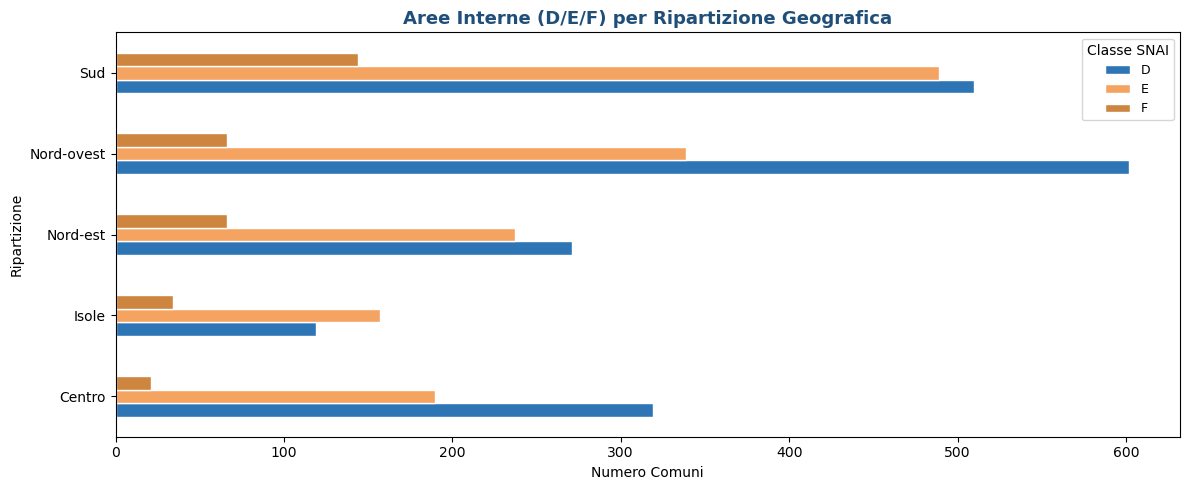

In [11]:
col = "classe_snai"
df_master[col] = df_master[col].astype(str)
pivot = df_master.groupby(["ripartizione", col]).size().unstack(fill_value=0)
print(pivot)

fig, ax = plt.subplots(figsize=(12, 5))
pivot[["D","E","F"]].plot(kind="barh", ax=ax,
    color=["#2E75B6","#F4A460","#CD853F"], edgecolor="white")
ax.set_title("Aree Interne (D/E/F) per Ripartizione Geografica",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.set_xlabel("Numero Comuni")
ax.set_ylabel("Ripartizione")
ax.legend(title="Classe SNAI", fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
df_master.to_csv(PROCESSED_DIR + "comuni_master.csv", index=False)
print("Salvato: comuni_master.csv")

col = "classe_snai"
print("Distribuzione classi SNAI nel master:")
print(df_master[col].value_counts().sort_index())
print()
print("Colonne disponibili:", df_master.columns.tolist())

Salvato: comuni_master.csv
Distribuzione classi SNAI nel master:
classe_snai
A       176
B        57
C      3710
D      1821
E      1412
F       331
nan     387
Name: count, dtype: int64

Colonne disponibili: ['Codice Regione', 'provincia', 'Codice Provincia (Storico)(1)', 'Progressivo del Comune (2)', 'codice_comune', 'Denominazione (Italiana e straniera)', 'comune', 'Denominazione altra lingua', 'cod_ripartizione', 'ripartizione', 'regione', "Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)", 'Tipologia di Unità territoriale sovracomunale ', 'capoluogo', 'sigla_prov', 'Codice Comune formato numerico', 'Codice Comune numerico con 107 Province (dal 2017 al 2025)', 'Codice Comune numerico con 110 Province (dal 2010 al 2016)', 'Codice Comune numerico con 107 Province (dal 2006 al 2009)', 'Codice Comune numerico con 103 Province (dal 1995 al 2005)', 'Codice Catastale del Comune', 'Codice NUTS1 2021', 'Codice NUTS2 2021 (3) ', 'Codice NUTS3 2021', 'Codice NU